In [55]:
# Necessary so that changes to an imported module will be seen by the next import statement
# https://stackoverflow.com/questions/64158622/jupyter-does-not-see-changes-in-the-imported-module
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
from oligo_maldi.experiment import Experiment
from oligo_maldi.sample import Sample
from oligo_maldi.oligo import Oligo
from oligo_maldi.helper import *

In [57]:
spectra = bruker_xml_to_spectra("../data/demo_data.xml")
samples = spectra_to_samples(spectra)
demo_experiment = Experiment(samples)

In [63]:
# template oligo
template = Oligo(name='Template (T)', seq='TGGTCTCCCT')

# Substrate oligos
base_seq = 'GGGAGACCACAACG'
ends = ['P', 'PP', 'PPP']       # possible 5' end chemistries
pol_events = 3                  # maximum number of polymerizations to check
dntps = ['A', 'T', 'C', 'G']    # dNTPs to use

oligos_starter = [Oligo(name=f"Sub, {end}", seq=base_seq, five_prime_end=end) for end in ['OH', 'P', 'PP', 'PPP']]

# Polymerized/modified oligos
oligos = {}
for dntp in dntps:
    for i in range(1, pol_events + 1):
        for end in ends:
            pol = dntp * i
            seq = pol + base_seq
            key = f"+{pol}, {end}"
            value = Oligo(name=key, seq=seq, five_prime_end=end)
            oligos[key] = value

oligos_a = [oligos[key] for key in oligos if 'A' in key]

oligos_all = oligos_starter + oligos_a + [template]

In [64]:
for sample in demo_experiment.samples.values():
    sample.mois = oligos_all

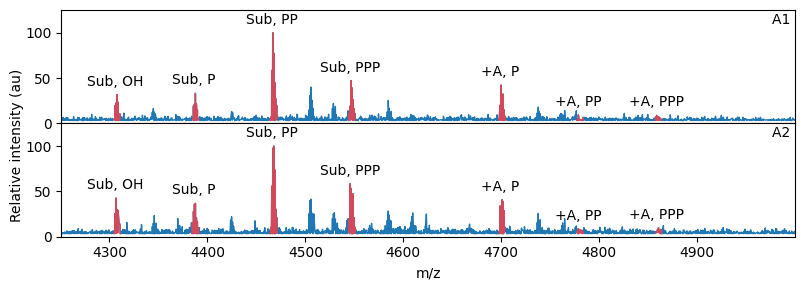

In [67]:
fig, ax = demo_experiment.stacked_plot(['A1', 'A2'], xlim=[4250,5000], filtered=False)

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': '+A, P / Sub, PPP'}>)

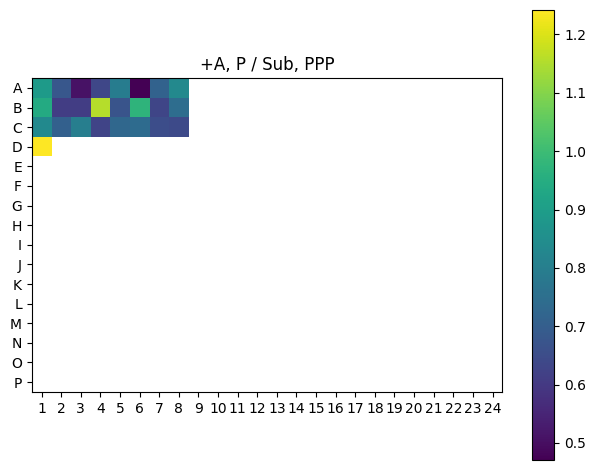

In [68]:
demo_experiment.heatmap(numerator='+A, P', denominator='Sub, PPP')

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Per sample signal intensity distribution'}, xlabel='Percent of data', ylabel='Relative signal'>)

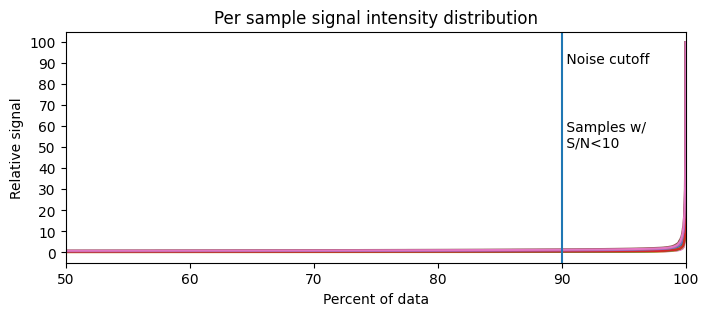

In [62]:
demo_experiment.sorted_signal_plot()

In [73]:
demo_experiment.write_to_excel('demo_experiment')

In [72]:
demo_experiment.report('demo_experiment_report')